In [1]:

from google.colab import drive, userdata

drive.mount('/content/drive')

GITHUB_TOKEN = userdata.get("GITHUB_TOKEN")

%cd /content
!git clone https://{GITHUB_TOKEN}@github.com/Bassey-data/Auto-insurance-claim-frequency.git

%cd /content/Auto-insurance-claim-frequency
!git config user.email "basseysamuel404@gmail.com"
!git config user.name "Bassey-data"
!git remote set-url origin https://{GITHUB_TOKEN}@github.com/Bassey-data/Auto-insurance-claim-frequency.git
!git checkout feature/comparison

print("Setup complete")

Mounted at /content/drive
/content
Cloning into 'Auto-insurance-claim-frequency'...
remote: Enumerating objects: 82, done.
remote: Counting objects: 100% (82/82), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 82 (delta 35), reused 49 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (82/82), 560.88 KiB | 8.63 MiB/s, done.
Resolving deltas: 100% (35/35), done.
/content/Auto-insurance-claim-frequency
Branch 'feature/comparison' set up to track remote branch 'feature/comparison' from 'origin'.
Switched to a new branch 'feature/comparison'
Setup complete


In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import statsmodels.api as sm
from sklearn.metrics import mean_poisson_deviance
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

print("Imports OK")

Imports OK


In [3]:
def parse_arff(path):
    columns = []
    data_start = None

    with open(path, "r", encoding="utf-8", errors="replace") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        stripped = line.strip()
        if stripped.lower().startswith("@attribute"):
            parts = stripped.split(maxsplit=2)
            columns.append(parts[1])
        elif stripped.lower().startswith("@data"):
            data_start = i + 1
            break

    data_lines = [l.strip() for l in lines[data_start:] if l.strip()]

    rows = []
    for line in data_lines:
        values = [v.strip().strip("'").strip('"') for v in line.split(",")]
        rows.append(values)

    return pd.DataFrame(rows, columns=columns)

In [5]:
def prepare_data():
    parquet_path = "data/processed/freMTPL2freq.parquet"
    if os.path.exists(parquet_path):
        df = pd.read_parquet(parquet_path)
    else:
        df = parse_arff("/content/drive/MyDrive/ACQsci.arff")
        df_converted = df.apply(pd.to_numeric, errors="ignore")
        for col in df_converted.select_dtypes(include="object").columns:
            df_converted[col] = df_converted[col].astype("category")
        df = df_converted
        os.makedirs("data/processed", exist_ok=True)
        df.to_parquet(parquet_path, index=False)

    # Apply caps
    df["VehAge"] = df["VehAge"].clip(upper=20)
    df["Exposure"] = df["Exposure"].clip(upper=1)
    df["ClaimNb"] = df["ClaimNb"].clip(upper=4)

    # Area ordinal encoding
    area_order = sorted(df["Area"].cat.categories)
    area_map = {cat: i for i, cat in enumerate(area_order)}
    df["Area_ord"] = df["Area"].map(area_map).astype(int)

    nominal_cols = ["VehBrand", "VehGas", "Region"]
    df["had_claim"] = (df["ClaimNb"] > 0).astype(int)
    train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["had_claim"])
    train_df = train_df.drop(columns="had_claim")
    test_df = test_df.drop(columns="had_claim")

    # GLM feature sets
    train_glm = pd.get_dummies(train_df, columns=nominal_cols, drop_first=True)
    test_glm = pd.get_dummies(test_df, columns=nominal_cols, drop_first=True)
    train_glm, test_glm = train_glm.align(test_glm, join="left", axis=1, fill_value=0)
    train_glm = train_glm.drop(columns="Area")
    test_glm = test_glm.drop(columns="Area")

    # GBM feature sets
    train_gbm = train_df.drop(columns="Area").copy()
    test_gbm = test_df.drop(columns="Area").copy()
    for col in nominal_cols:
        train_gbm[col] = train_gbm[col].astype("category")
        test_gbm[col] = test_gbm[col].astype("category")

    # Save all four
    os.makedirs("data/processed", exist_ok=True)
    train_glm.to_parquet("data/processed/train_glm.parquet", index=False)
    test_glm.to_parquet("data/processed/test_glm.parquet", index=False)
    train_gbm.to_parquet("data/processed/train_gbm.parquet", index=False)
    test_gbm.to_parquet("data/processed/test_gbm.parquet", index=False)

    print("Data ready")
    return train_glm, test_glm, train_gbm, test_gbm


# Check if files exist, regenerate if not
if not os.path.exists("data/processed/train_glm.parquet"):
    train_glm, test_glm, train_gbm, test_gbm = prepare_data()
else:
    train_glm = pd.read_parquet("data/processed/train_glm.parquet")
    test_glm = pd.read_parquet("data/processed/test_glm.parquet")
    train_gbm = pd.read_parquet("data/processed/train_gbm.parquet")
    test_gbm = pd.read_parquet("data/processed/test_gbm.parquet")
    print("Loaded from parquet")

print(f"GLM train: {train_glm.shape}, GBM train: {train_gbm.shape}")

Loaded from parquet
GLM train: (542410, 41), GBM train: (542410, 12)


Retrain both models

In [6]:
# Poisson GLM
feature_cols_glm = [c for c in train_glm.columns if c not in ("IDpol", "ClaimNb", "Exposure")]

X_train_glm = train_glm[feature_cols_glm].astype(float)
y_train = train_glm["ClaimNb"]
offset_train = np.log(train_glm["Exposure"])

X_test_glm = test_glm[feature_cols_glm].astype(float)
y_test = test_glm["ClaimNb"]
offset_test = np.log(test_glm["Exposure"])

X_train_sm = sm.add_constant(X_train_glm)
X_test_sm = sm.add_constant(X_test_glm, has_constant="add")

glm_model = sm.GLM(y_train, X_train_sm, family=sm.families.Poisson(), offset=offset_train)
glm_result = glm_model.fit()

glm_test_pred = glm_result.predict(X_test_sm, offset=offset_test)

print("GLM trained")

GLM trained


In [8]:
# LightGBM
feature_cols_gbm = [c for c in train_gbm.columns if c not in ("IDpol", "ClaimNb", "Exposure")]
categorical_cols = [c for c in feature_cols_gbm if train_gbm[c].dtype.name == "category"]

X_train_gbm = train_gbm[feature_cols_gbm]
X_test_gbm = test_gbm[feature_cols_gbm]
exposure_test = test_gbm["Exposure"]
offset_train_gbm = np.log(train_gbm["Exposure"])
offset_test_gbm = np.log(test_gbm["Exposure"])

train_set = lgb.Dataset(
    X_train_gbm, label=y_train,
    init_score=offset_train_gbm,
    categorical_feature=categorical_cols,
    free_raw_data=False
)

valid_set = lgb.Dataset(
    X_test_gbm, label=y_test,
    init_score=offset_test_gbm,
    categorical_feature=categorical_cols,
    reference=train_set,
    free_raw_data=False
)

params = {
    "objective": "poisson",
    "metric": "poisson",
    "learning_rate": 0.03,
    "num_leaves": 15,
    "min_data_in_leaf": 500,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "lambda_l2": 1.0,
    "verbose": -1,
    "seed": 42,
}

gbm_model = lgb.train(
    params, train_set,
    num_boost_round=2000,
    valid_sets=[train_set, valid_set],
    valid_names=["train", "valid"],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(500)],
)

raw_test_pred = gbm_model.predict(X_test_gbm, num_iteration=gbm_model.best_iteration, raw_score=True)
gbm_test_pred = np.exp(raw_test_pred + offset_test_gbm.values)

print(f"\nLightGBM trained - best iteration: {gbm_model.best_iteration}")

Training until validation scores don't improve for 50 rounds
[500]	train's poisson: 0.200123	valid's poisson: 0.200575
[1000]	train's poisson: 0.198663	valid's poisson: 0.200059
[1500]	train's poisson: 0.197593	valid's poisson: 0.199856
[2000]	train's poisson: 0.19666	valid's poisson: 0.199726
Did not meet early stopping. Best iteration is:
[1985]	train's poisson: 0.196687	valid's poisson: 0.199725

LightGBM trained - best iteration: 1985


In [9]:
# Naive baseline
naive_freq = y_train.sum() / train_glm["Exposure"].sum()
naive_pred_test = naive_freq * test_glm["Exposure"]
naive_deviance = mean_poisson_deviance(y_test, naive_pred_test)

# Deviance for each model
glm_deviance = mean_poisson_deviance(y_test, glm_test_pred)
gbm_deviance = mean_poisson_deviance(y_test, gbm_test_pred)

# Lorenz curve and Gini
def lorenz_curve(y_true, y_pred, exposure):
    order = np.argsort(y_pred)
    y_true_sorted = np.array(y_true)[order]
    exposure_sorted = np.array(exposure)[order]
    cum_exposure = np.cumsum(exposure_sorted) / exposure_sorted.sum()
    cum_claims = np.cumsum(y_true_sorted) / y_true_sorted.sum()
    return cum_exposure, cum_claims

def gini_index(cum_exposure, cum_claims):
    return 1 - 2 * np.trapezoid(cum_claims, cum_exposure)

cum_exp_glm, cum_claims_glm = lorenz_curve(y_test, glm_test_pred, test_glm["Exposure"])
cum_exp_gbm, cum_claims_gbm = lorenz_curve(y_test, gbm_test_pred, exposure_test)

gini_glm = gini_index(cum_exp_glm, cum_claims_glm)
gini_gbm = gini_index(cum_exp_gbm, cum_claims_gbm)

# Summary table
results = pd.DataFrame({
    "Model": ["Naive baseline", "Poisson GLM", "LightGBM"],
    "Test Deviance": [naive_deviance, glm_deviance, gbm_deviance],
    "Deviance improvement vs naive": [
        0,
        (1 - glm_deviance / naive_deviance) * 100,
        (1 - gbm_deviance / naive_deviance) * 100
    ],
    "Gini index": [0, gini_glm, gini_gbm]
})

results = results.round(4)
print(results.to_string(index=False))

         Model  Test Deviance  Deviance improvement vs naive  Gini index
Naive baseline         0.3294                         0.0000      0.0000
   Poisson GLM         0.3191                         3.1120     -0.0473
      LightGBM         0.3016                         8.4477      0.1010


Lorenz curve

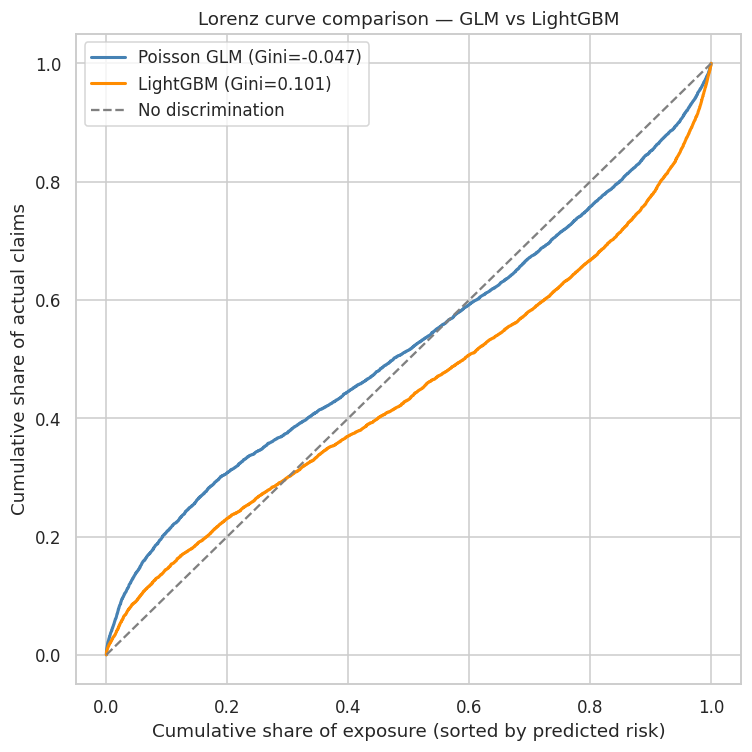

In [10]:
plt.figure(figsize=(7, 7))

# GLM curve
plt.plot(cum_exp_glm, cum_claims_glm,
         label=f"Poisson GLM (Gini={gini_glm:.3f})",
         color="steelblue", linewidth=2)

# LightGBM curve
plt.plot(cum_exp_gbm, cum_claims_gbm,
         label=f"LightGBM (Gini={gini_gbm:.3f})",
         color="darkorange", linewidth=2)

# Diagonal - no discrimination
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="No discrimination")

plt.xlabel("Cumulative share of exposure (sorted by predicted risk)")
plt.ylabel("Cumulative share of actual claims")
plt.title("Lorenz curve comparison — GLM vs LightGBM")
plt.legend()
plt.tight_layout()
plt.show()

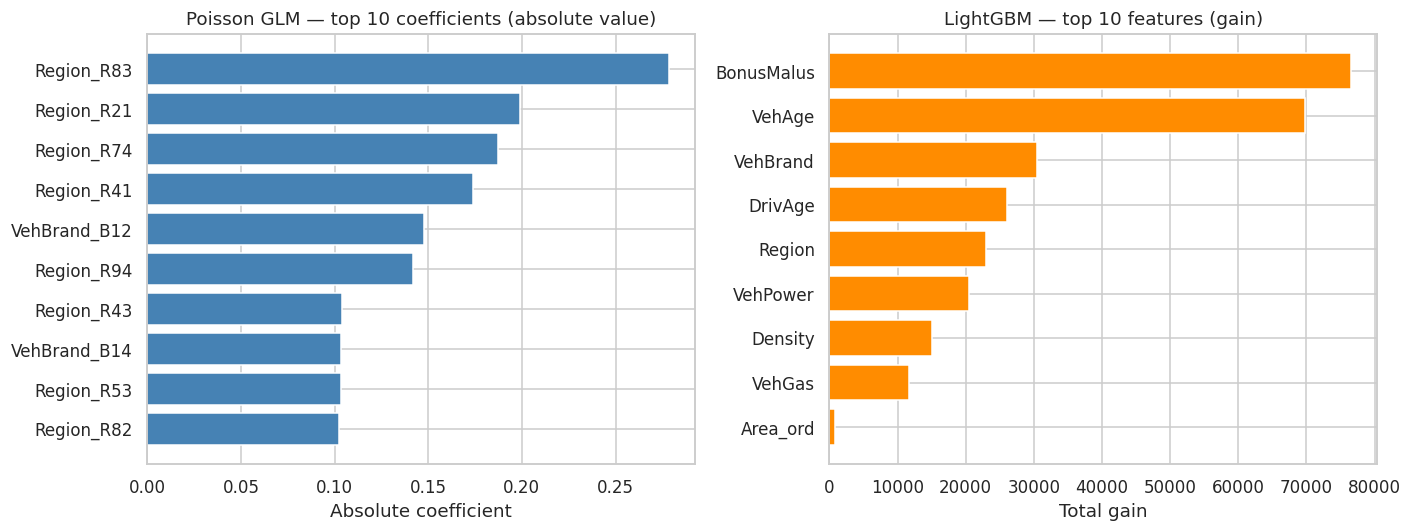

In [11]:
# GLM coefficients (top 10 by absolute value, excluding intercept)
glm_coef = pd.DataFrame({
    "feature": glm_result.params.index,
    "coefficient": glm_result.params.values
}).query("feature != 'const'")
glm_coef["abs_coef"] = glm_coef["coefficient"].abs()
glm_coef = glm_coef.sort_values("abs_coef", ascending=False).head(10)

# LightGBM importance (top 10 by gain)
gbm_imp = pd.DataFrame({
    "feature": gbm_model.feature_name(),
    "importance": gbm_model.feature_importance(importance_type="gain")
}).sort_values("importance", ascending=False).head(10)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(glm_coef["feature"][::-1], glm_coef["abs_coef"][::-1], color="steelblue")
axes[0].set_title("Poisson GLM — top 10 coefficients (absolute value)")
axes[0].set_xlabel("Absolute coefficient")

axes[1].barh(gbm_imp["feature"][::-1], gbm_imp["importance"][::-1], color="darkorange")
axes[1].set_title("LightGBM — top 10 features (gain)")
axes[1].set_xlabel("Total gain")

plt.tight_layout()
plt.show()

In [ ]:
print("=" * 55)
print("MODEL COMPARISON SUMMARY")
print("=" * 55)
print(f"Portfolio frequency:       {y_train.sum() / train_glm['Exposure'].sum():.4f}")
print(f"Zero-claim policies:       {(y_test == 0).mean() * 100:.1f}%")
print()
print(f"{'Model':<20} {'Deviance':>10} {'vs Naive':>10} {'Gini':>8}")
print("-" * 55)
print(f"{'Naive baseline':<20} {naive_deviance:>10.4f} {'0.0%':>10} {'0.000':>8}")
print(f"{'Poisson GLM':<20} {glm_deviance:>10.4f} {(1-glm_deviance/naive_deviance)*100:>9.1f}% {gini_glm:>8.3f}")
print(f"{'LightGBM':<20} {gbm_deviance:>10.4f} {(1-gbm_deviance/naive_deviance)*100:>9.1f}% {gini_gbm:>8.3f}")
print("=" * 55)
print()
print("Key finding: LightGBM's advantage is driven by its")
print("ability to capture VehAge's non-linear relationship,")
print("which the GLM's single linear term cannot represent.")